# Packages

In [1]:
import cell2location

In [2]:
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

In [3]:

from scipy import sparse # Dealing with adata data dyptes numbers

In [4]:

import torch
torch.set_float32_matmul_precision("high")  # or "medium"
# to deal with this warning
# You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. 
# To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` 
# which will trade-off precision for performance. For more details, read 
# https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision

## SC: GPU

In [5]:
# SC for GPU
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (torch):", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))


Torch version: 2.5.1
CUDA available: True
CUDA version (torch): 12.4
GPU count: 1
Current device: 0
Device name: NVIDIA A100-PCIE-40GB


In [6]:
import torch, scvi
print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))

2.5.1 True NVIDIA A100-PCIE-40GB


# Data

## Locations

In [7]:
proj_folder   = Path("/home/janzules/spatial/CAR-T/data/cell2location")
input_folder  = proj_folder / "cell2location_inputs"

# ref_loc       = input_folder / "ref_adata_c2l_model.h5ad"  saved adata_file with the training at:
spatial_loc   = input_folder / "spatial_sdata_c2l_model.h5ad"

# Output location
ref_run_name   = proj_folder / "reference_signatures"
run_name       = proj_folder / "cell2location_map"

# After training
adata_ref_file     = ref_run_name / "sc_with_signatures.h5ad" # 

## Data Prep - sdata

In [8]:
# Loading Data

adata_vis = sc.read_h5ad(spatial_loc)
adata_ref = sc.read_h5ad(adata_ref_file)


In [9]:
# Changing the datatype

# spatial
adata_vis.X = adata_vis.X.tocsr()
adata_vis.X.data = adata_vis.X.data.astype(np.float32)


In [10]:

# Creating the column that will match the sc reference
adata_vis.obs['treatment'] = adata_vis.obs['condition'].astype(str)

# Convert tumor_loc robustly: category -> string -> numeric
adata_vis.obs['tumor_loc'] = pd.to_numeric(
    adata_vis.obs['tumor_loc'].astype(str).str.strip(),
    errors='coerce'
).astype('Int64')  # nullable integer dtype

tumor_locations = [1, 2]

for tumor in tumor_locations:
    suffix = f"_Tu{tumor}"
    tum_loc_mask = adata_vis.obs["tumor_loc"].eq(tumor)

    adata_vis.obs.loc[tum_loc_mask, 'treatment'] = (
        adata_vis.obs.loc[tum_loc_mask, 'treatment']
        .str.replace(r"T72", "TAG72", regex=True)
        + suffix
    )


In [11]:
# Creating batch_core label that contains TMA+Mouse Tissue label together.
adata_vis.obs["batch_core"] = (
    adata_vis.obs["TMA"].astype(str) + "__" +
    adata_vis.obs["tissue"].astype(str)
).astype("category")

### MT removal

In [12]:
# Quick checks
print(adata_vis.shape, adata_ref.shape)
print("vis var_names example:", adata_vis.var_names[:3].tolist())
print("ref var_names example:", adata_ref.var_names[:3].tolist())
print("vis SYMBOL example:", adata_vis.var["SYMBOL"].head().tolist() if "SYMBOL" in adata_vis.var else "NO SYMBOL")
print("ref SYMBOL example:", adata_ref.var["SYMBOL"].head().tolist() if "SYMBOL" in adata_ref.var else "NO SYMBOL")

# Optional but recommended: remove mitochondrial genes for mapping (based on SYMBOL, not var_names)
if "SYMBOL" not in adata_vis.var.columns:
    raise ValueError("adata_vis.var['SYMBOL'] not found. Needed to filter mitochondrial genes with Ensembl var_names.")

sym_vis = adata_vis.var["SYMBOL"].astype(str).fillna("")
mt_mask = sym_vis.str.startswith(("mt-", "MT-")).to_numpy()

# Save which MT genes you're about to remove (must be done BEFORE filtering)
removed_mt = adata_vis.var.loc[mt_mask, ["SYMBOL"]].copy()
removed_mt["ensembl"] = adata_vis.var_names[mt_mask].to_numpy()

# QC metric: MT counts per segmented cell
adata_vis.obs["mt_counts"] = np.asarray(adata_vis[:, mt_mask].X.sum(axis=1)).ravel() if mt_mask.any() else 0

# Now remove MT genes
adata_vis = adata_vis[:, ~mt_mask].copy()
print("After MT removal:", adata_vis.shape)
print("MT genes removed:", int(mt_mask.sum()))


(427296, 16784) (135379, 12141)
vis var_names example: ['ENSMUSG00000051951', 'ENSMUSG00000025900', 'ENSMUSG00000025902']
ref var_names example: ['ENSMUSG00000051951', 'ENSMUSG00000025900', 'ENSMUSG00000025902']
vis SYMBOL example: ['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1']
ref SYMBOL example: ['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1']
After MT removal: (427296, 16771)
MT genes removed: 13


In [13]:

# ref_loc       = input_folder / "ref_adata_c2l_model.h5ad"  saved adata_file with the training at:
spatial_clean_loc   = input_folder / "spatial_sdata_c2l_model_cleaned.h5ad"
adata_vis.write(spatial_clean_loc)

## Loading sdata parameters

In [13]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,B/T_cell,B_cell,CAR_T_cell,DC,Endothelial
gene_id,,,,,
ENSMUSG00000051951,0.031992,0.001949,0.002054,0.003468,0.008911
ENSMUSG00000025900,0.019777,0.000429,0.003582,0.000244,0.010231
ENSMUSG00000025902,0.007540,0.000168,0.001827,0.000199,0.637525
ENSMUSG00000025903,0.329970,0.111627,0.032036,0.310520,0.201191
ENSMUSG00000033813,0.959093,0.412800,0.074074,0.758402,0.274767


# Training spatial

## Mapping

In [14]:
# find shared genes and subset both anndata and reference signatures
# MT was removed from vis data, and the infe_aver selected the most relevant genes for annotating
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)

In [15]:
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="TMA")

## Training

In [16]:
# create and train the model
mod = cell2location.models.Cell2location(
    adata_vis, cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=1.5,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.1.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'TMA',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   4    │
│         n_cells          │ 427296 │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   1    │
│          n_vars          │ 12128  │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['TMA'] │   F07839   │          0          │
│                  │   F07840   │          1          │
│                  │   F08542   │          2          │
│                  │   F08543   │          3          │
└──────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [17]:
torch.cuda.empty_cache()

epoch_num = 450
batch_num = 16384 #4096, 8192, 16384, 32768
mod.train(
    max_epochs=epoch_num,
    batch_size=batch_num,
    train_size=1,
    lr=0.002,
    num_particles=1
)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skip

Training:   0%|          | 0/450 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=450` reached.


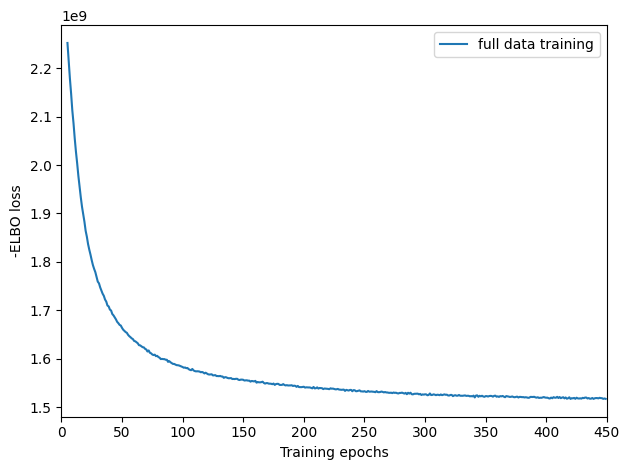

In [18]:
# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(5)
plt.legend(labels=['full data training']);
# mod.train(max_epochs=30000,
#           # train using full data (batch_size=None)
#           batch_size=None,
#           # use all data points in training because
#           # we need to estimate cell abundance at all locations
#           train_size=1
#          )

## Saving predictions

In [ ]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_vis = mod.export_posterior(
    adata_vis, 
    sample_kwargs={'num_samples': 450, 'batch_size': batch_num}
)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...


Sampling local variables, batch:   0%|          | 0/27 [00:00<?, ?it/s]

In [ ]:
adata_vis = mod.export_posterior(
    adata_vis,
    use_quantiles=True,
    add_to_obsm=["q50"],
    sample_kwargs={"batch_size": batch_num},
)

In [ ]:
# Save model
mod.save(f"{run_name}", overwrite=True)

In [ ]:
# mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)

# Save anndata object with results
adata_file = f"{run_name}/sp_{epoch_num}_epochs.h5ad"
adata_vis.write(adata_file)
adata_file

In [ ]:
mod.plot_QC()

In [ ]:
fig = mod.plot_spatial_QC_across_batches()